# 1D-ARC Meta-Learning Demo
**Interactive evaluation of trained meta-learning models on 1D-ARC tasks**

This notebook lets you:
1. Choose a trained model (Matching Networks, FOMAML, ANIL, CNP, Reptile, ProtoNet)
2. Pick a test task from the dataset **or create your own custom task**
3. See the model adapt from 3 examples and predict the test output
4. Visualize input/output with colored grids

## Environment Setup
Use the **`base`** conda environment:
```bash
conda activate base
jupyter notebook
```
Required packages (all pre-installed in base): `torch 2.7+`, `scipy`, `pandas`, `numpy`, `matplotlib`, `tqdm`, `ipywidgets`

In [5]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import json, os, sys, glob, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, HTML
import ipywidgets as widgets

sys.path.insert(0, '.')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Visualization Helpers

In [6]:
# ARC color palette (0-9)
ARC_COLORS = [
    '#000000',  # 0: black
    '#0074D9',  # 1: blue
    '#FF4136',  # 2: red
    '#2ECC40',  # 3: green
    '#FFDC00',  # 4: yellow
    '#AAAAAA',  # 5: gray
    '#F012BE',  # 6: magenta
    '#FF851B',  # 7: orange
    '#7FDBFF',  # 8: cyan
    '#870C25',  # 9: maroon
]

def plot_1d_sequence(seq, ax, title='', highlight_errors=None):
    """Plot a 1D ARC sequence as colored cells."""
    seq = [s for s in seq if s < 10]  # remove padding
    n = len(seq)
    for i, val in enumerate(seq):
        color = ARC_COLORS[val] if val < 10 else '#FFFFFF'
        edgecolor = 'red' if highlight_errors is not None and i < len(highlight_errors) and highlight_errors[i] else 'gray'
        linewidth = 2.5 if edgecolor == 'red' else 0.5
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor=edgecolor, linewidth=linewidth))
        if val > 0:
            ax.text(i + 0.5, 0.5, str(val), ha='center', va='center', fontsize=8,
                    color='white' if val in [0, 9] else 'black', fontweight='bold')
    ax.set_xlim(0, max(n, 1)); ax.set_ylim(0, 1)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

def visualize_task(task_data, prediction=None, title=''):
    """Visualize a full ARC task with optional prediction."""
    train = task_data['train']
    test = task_data['test'][0]
    n_rows = len(train) + (2 if prediction is not None else 1)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 1.2 * n_rows))
    if n_rows == 1: axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    for i, ex in enumerate(train):
        inp = ex['input'][0] if isinstance(ex['input'][0], list) else ex['input']
        out = ex['output'][0] if isinstance(ex['output'][0], list) else ex['output']
        plot_1d_sequence(inp, axes[i][0], f'Train {i+1} Input')
        plot_1d_sequence(out, axes[i][1], f'Train {i+1} Output')
    
    test_inp = test['input'][0] if isinstance(test['input'][0], list) else test['input']
    test_out = test['output'][0] if isinstance(test['output'][0], list) else test['output']
    row = len(train)
    plot_1d_sequence(test_inp, axes[row][0], 'Test Input')
    plot_1d_sequence(test_out, axes[row][1], 'Ground Truth Output')
    
    if prediction is not None:
        errors = [p != g for p, g in zip(prediction, test_out[:len(prediction)])]
        plot_1d_sequence(prediction, axes[row+1][0], 'Model Prediction')
        em = int(prediction == test_out[:len(prediction)])
        n_correct = sum(1 for p, g in zip(prediction, test_out) if p == g)
        axes[row+1][1].text(0.5, 0.5, f'EM: {"PASS" if em else "FAIL"}\n'
                           f'Token Acc: {n_correct}/{len(test_out)} ({n_correct/len(test_out)*100:.0f}%)',
                           ha='center', va='center', fontsize=14,
                           color='green' if em else 'red', fontweight='bold',
                           transform=axes[row+1][1].transAxes)
        axes[row+1][1].set_xlim(0, 1); axes[row+1][1].set_ylim(0, 1)
        axes[row+1][1].set_xticks([]); axes[row+1][1].set_yticks([])
        # Also highlight errors in prediction
        axes[row+1][0].clear()
        plot_1d_sequence(prediction, axes[row+1][0], 'Model Prediction (red border = error)', highlight_errors=errors)
    
    plt.tight_layout()
    plt.show()

print('Visualization helpers loaded.')

Visualization helpers loaded.


## 2. Load Models

In [7]:
# Available models and their configs
MODEL_CONFIGS = {
    'Matching Networks (EM=61.8%)': {
        'module': 'arc_matching', 'class': 'MatchingNetwork', 'ckpt': 'checkpoints_arc_matching/best_model.pt',
        'init_args': {}, 'inner_steps': 0, 'needs_masks': True,
    },
    'FOMAML (EM=56.6%)': {
        'module': 'arc_fomaml', 'class': 'ArcModel', 'ckpt': 'checkpoints_arc_fomaml/best_model.pt',
        'init_args': {}, 'inner_steps': 5, 'needs_masks': False,
    },
    'ANIL (EM=55.9%)': {
        'module': 'arc_anil', 'class': 'ANILArcModel', 'ckpt': 'checkpoints_arc_anil/best_model.pt',
        'init_args': {}, 'inner_steps': 5, 'needs_masks': False, 'head_only': True,
    },
    'CNP (EM=52.9%)': {
        'module': 'arc_cnp', 'class': 'ARCCNP', 'ckpt': 'checkpoints_arc_cnp/best_model.pt',
        'init_args': {}, 'inner_steps': 0, 'needs_masks': True,
    },
    'Reptile is10 (EM=38.2%)': {
        'module': 'arc_reptile', 'class': 'ARC1DModel', 'ckpt': 'checkpoints_arc_reptile/best_model.pt',
        'init_args': {}, 'inner_steps': 10, 'needs_masks': False,
    },
}

PAD = 10

def load_model(config):
    mod = __import__(config['module'])
    cls = getattr(mod, config['class'])
    model = cls(**config['init_args'])
    model.load_state_dict(torch.load(config['ckpt'], map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()
    return model

def pad_seq(seq, max_len=100):
    return seq[:max_len] + [PAD] * max(0, max_len - len(seq))

def prepare_task(task_data, max_len=100):
    """Convert raw JSON task to tensors."""
    train = task_data['train']
    test = task_data['test'][0]
    
    support_inputs, support_outputs, support_masks = [], [], []
    for ex in train:
        inp = ex['input'][0] if isinstance(ex['input'][0], list) else ex['input']
        out = ex['output'][0] if isinstance(ex['output'][0], list) else ex['output']
        out_padded = pad_seq(out, max_len)
        mask = [1.0 if i < len(out) else 0.0 for i in range(max_len)]
        support_inputs.append(pad_seq(inp, max_len))
        support_outputs.append(out_padded)
        support_masks.append(mask)
    
    test_inp = test['input'][0] if isinstance(test['input'][0], list) else test['input']
    test_out = test['output'][0] if isinstance(test['output'][0], list) else test['output']
    test_out_padded = pad_seq(test_out, max_len)
    test_mask = [1.0 if i < len(test_out) else 0.0 for i in range(max_len)]
    
    return {
        'support_inputs': torch.tensor(support_inputs, dtype=torch.long).to(device),
        'support_outputs': torch.tensor(support_outputs, dtype=torch.long).to(device),
        'support_masks': torch.tensor(support_masks, dtype=torch.float).to(device),
        'query_input': torch.tensor(pad_seq(test_inp, max_len), dtype=torch.long).to(device),
        'query_output': torch.tensor(test_out_padded, dtype=torch.long).to(device),
        'query_mask': torch.tensor(test_mask, dtype=torch.float).to(device),
        'raw_output_len': len(test_out),
    }

print(f'Available models: {list(MODEL_CONFIGS.keys())}')

Available models: ['Matching Networks (EM=61.8%)', 'FOMAML (EM=56.6%)', 'ANIL (EM=55.9%)', 'CNP (EM=52.9%)', 'Reptile is10 (EM=38.2%)']


## 3. Inference Engine

In [8]:
def predict(model, task_tensors, config):
    """Run meta-learning inference: adapt on support, predict on query."""
    si = task_tensors['support_inputs']
    so = task_tensors['support_outputs']
    sm = task_tensors['support_masks']
    qi = task_tensors['query_input']
    qm = task_tensors['query_mask']
    out_len = task_tensors['raw_output_len']
    inner_steps = config['inner_steps']
    
    if inner_steps > 0:
        # Optimization-based: adapt on support set
        ow = {n: p.data.clone() for n, p in model.named_parameters()}
        if config.get('head_only'):
            params = [p for n, p in model.named_parameters() if 'head' in n or 'dec' in n]
        else:
            params = list(model.parameters())
        iopt = optim.SGD(params, lr=0.01)
        model.train()
        K = si.size(0)
        for _ in range(inner_steps):
            for j in range(K):
                ctx_idx = [k for k in range(K) if k != j]
                ci = si[ctx_idx] if ctx_idx else si[j:j+1]
                co = so[ctx_idx] if ctx_idx else so[j:j+1]
                logits = model(ci, co, si[j])
                loss = F.cross_entropy(logits, so[j], reduction='none', ignore_index=PAD)
                loss = (loss * sm[j]).sum() / sm[j].sum().clamp(min=1)
                iopt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 10.0)
                iopt.step()
        
        model.eval()
        with torch.no_grad():
            logits = model(si, so, qi)
            pred = logits.argmax(dim=-1).cpu().tolist()[:out_len]
        
        # Restore weights
        with torch.no_grad():
            for n, p in model.named_parameters(): p.data = ow[n]
    else:
        # Model-based / Metric-based: no inner loop
        model.eval()
        with torch.no_grad():
            if config['needs_masks']:
                logits = model(si, so, qi, sm, qm)
            else:
                logits = model(si, so, qi)
            pred = logits.argmax(dim=-1).cpu().tolist()[:out_len]
    
    return pred

print('Inference engine ready.')

Inference engine ready.


## 4. Choose Model & Run

In [9]:
# ============================
# CHOOSE YOUR MODEL HERE
# ============================
MODEL_NAME = 'Matching Networks (EM=61.8%)'  # <-- Change this to try different models

# Options:
#   'Matching Networks (EM=61.8%)'
#   'FOMAML (EM=56.6%)'
#   'ANIL (EM=55.9%)'
#   'CNP (EM=52.9%)'
#   'Reptile is10 (EM=38.2%)'

config = MODEL_CONFIGS[MODEL_NAME]
print(f'Loading {MODEL_NAME}...')
model = load_model(config)
print(f'Loaded! Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading Matching Networks (EM=61.8%)...
Loaded! Parameters: 285,322


## 5A. Test on Dataset Tasks
Pick a task from the 1D-ARC test set and see how the model performs.

In [10]:
# Load all test tasks
task_files = sorted(glob.glob('1D-ARC/dataset/*/*.json'))
print(f'Total tasks: {len(task_files)}')
print(f'Task types: {sorted(set(os.path.basename(os.path.dirname(f)) for f in task_files))}')

# Use the test split (last 15%)
test_start = int(0.85 * len(task_files))
test_files = task_files[test_start:]
print(f'Test tasks: {len(test_files)}')

Total tasks: 901
Task types: ['1d_denoising_1c', '1d_denoising_mc', '1d_fill', '1d_flip', '1d_hollow', '1d_mirror', '1d_move_1p', '1d_move_2p', '1d_move_2p_dp', '1d_move_3p', '1d_move_dp', '1d_padded_fill', '1d_pcopy_1c', '1d_pcopy_mc', '1d_recolor_cmp', '1d_recolor_cnt', '1d_recolor_oe', '1d_scale_dp']
Test tasks: 136


Task 22: 1d_recolor_cnt_42.json (type: 1d_recolor_cnt)


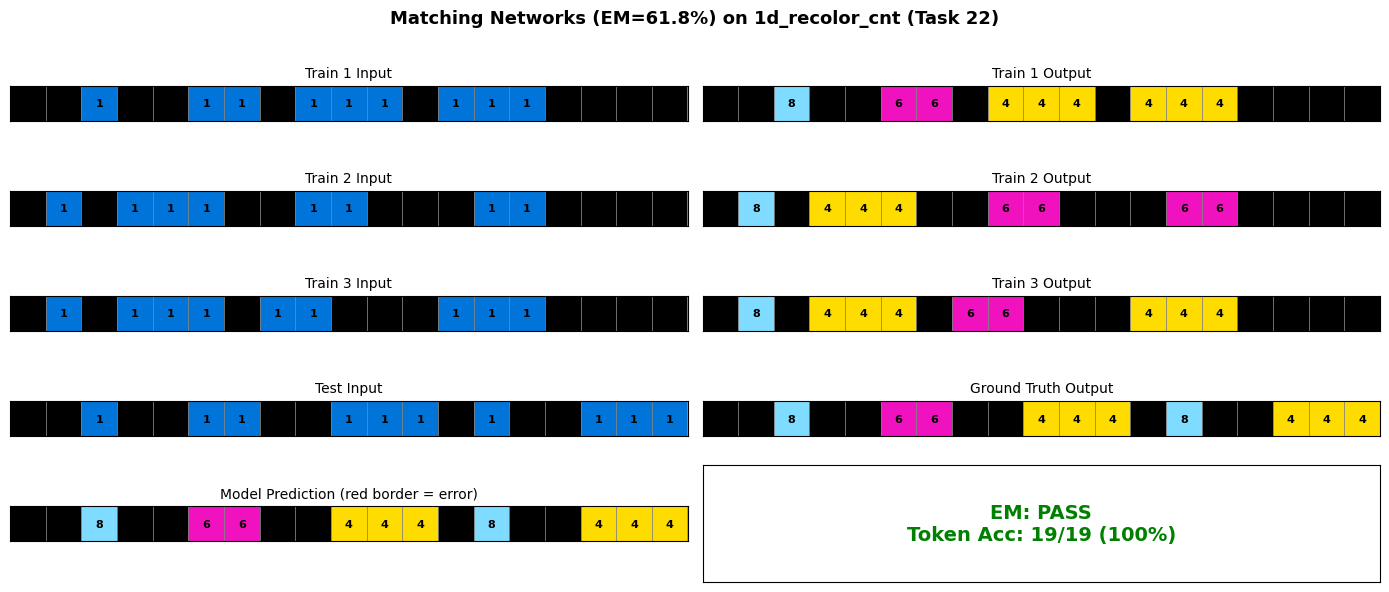

In [18]:
# ============================
# CHOOSE TASK INDEX or 'random'
# ============================
TASK_IDX = 'random'  # <-- Set to an integer (0-135) or 'random'

if TASK_IDX == 'random':
    TASK_IDX = random.randint(0, len(test_files) - 1)

task_path = test_files[TASK_IDX]
task_type = os.path.basename(os.path.dirname(task_path))
task_data = json.load(open(task_path))

print(f'Task {TASK_IDX}: {os.path.basename(task_path)} (type: {task_type})')

# Prepare and predict
task_tensors = prepare_task(task_data)
prediction = predict(model, task_tensors, config)

# Get ground truth
test_out = task_data['test'][0]['output'][0] if isinstance(task_data['test'][0]['output'][0], list) else task_data['test'][0]['output']

# Visualize
visualize_task(task_data, prediction=prediction,
               title=f'{MODEL_NAME} on {task_type} (Task {TASK_IDX})')

## 5B. Create Your Own Custom Task
Design a custom 1D transformation and see if the model can learn the rule from your examples!

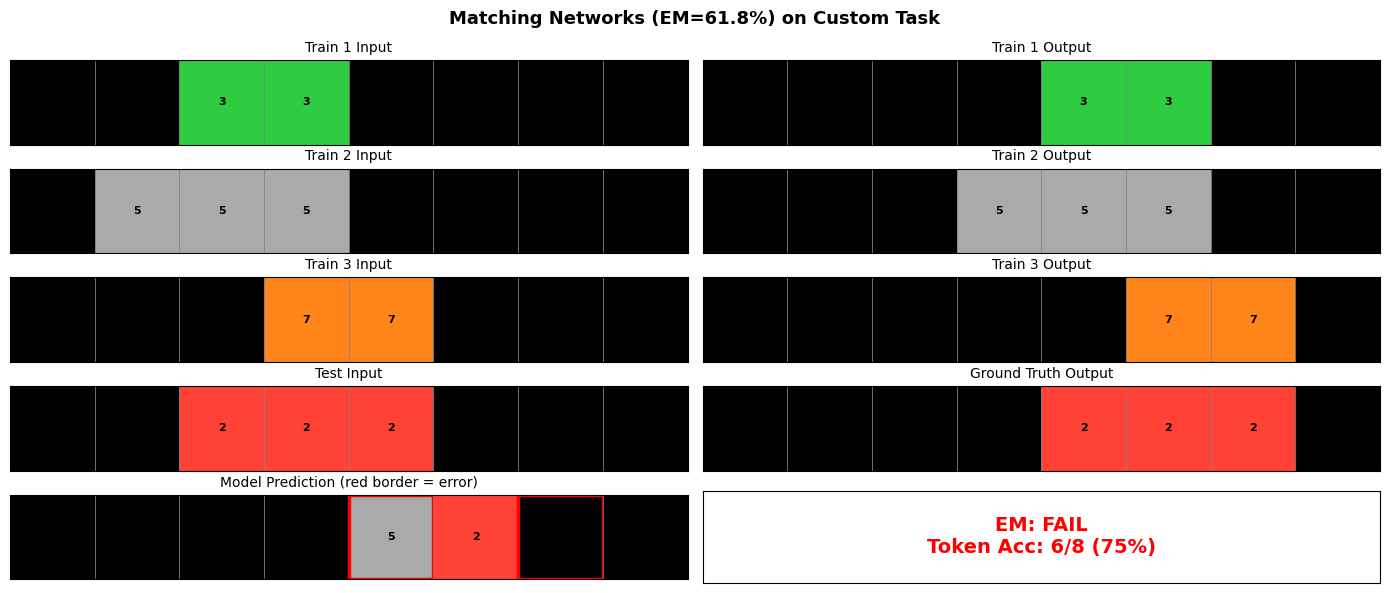

In [21]:
# ============================
# DESIGN YOUR OWN TASK
# ============================
# Each example has an input and output (lists of integers 0-9).
# Provide 3 training examples that demonstrate a rule,
# and 1 test input for the model to predict.
#
# Example: "shift everything 2 positions to the right"

custom_task = {
    'train': [
        {'input': [[0, 0, 3, 3, 0, 0, 0, 0]], 'output': [[0, 0, 0, 0, 3, 3, 0, 0]]},
        {'input': [[0, 5, 5, 5, 0, 0, 0, 0]], 'output': [[0, 0, 0, 5, 5, 5, 0, 0]]},
        {'input': [[0, 0, 0, 7, 7, 0, 0, 0]], 'output': [[0, 0, 0, 0, 0, 7, 7, 0]]},
    ],
    'test': [
        {'input': [[0, 0, 2, 2, 2, 0, 0, 0]], 'output': [[0, 0, 0, 0, 2, 2, 2, 0]]},  # expected
    ]
}

# Prepare and predict
task_tensors = prepare_task(custom_task)
prediction = predict(model, task_tensors, config)

# Visualize
visualize_task(custom_task, prediction=prediction, title=f'{MODEL_NAME} on Custom Task')

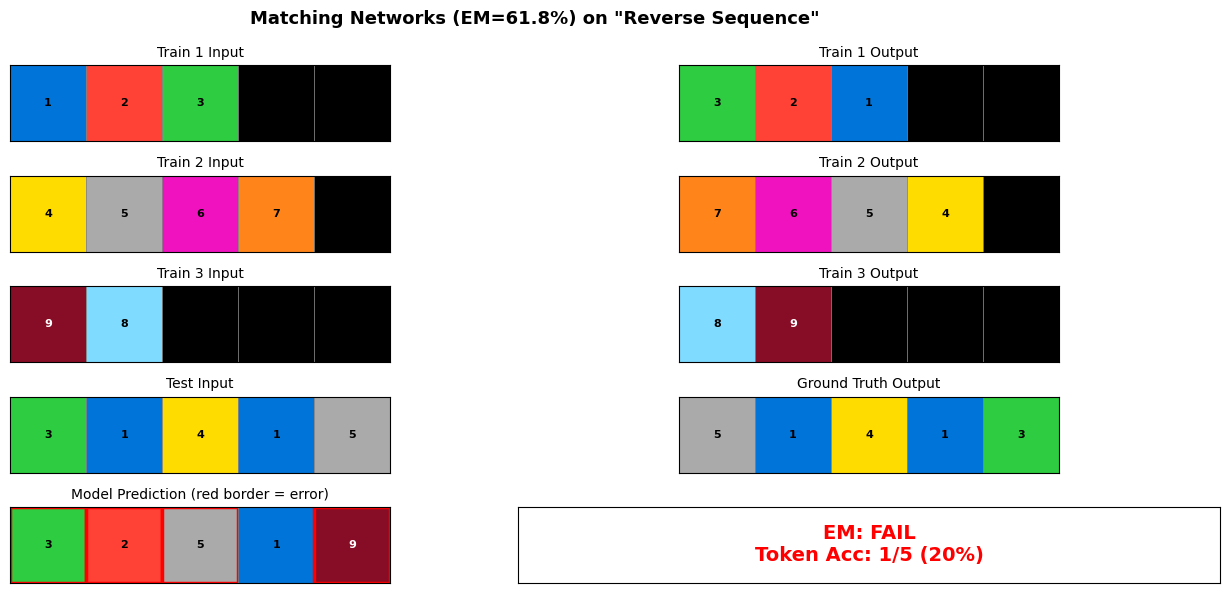

In [22]:
# ============================
# TRY ANOTHER CUSTOM TASK: "reverse the sequence"
# ============================

custom_task_2 = {
    'train': [
        {'input': [[1, 2, 3, 0, 0]], 'output': [[3, 2, 1, 0, 0]]},
        {'input': [[4, 5, 6, 7, 0]], 'output': [[7, 6, 5, 4, 0]]},
        {'input': [[9, 8, 0, 0, 0]], 'output': [[8, 9, 0, 0, 0]]},
    ],
    'test': [
        {'input': [[3, 1, 4, 1, 5]], 'output': [[5, 1, 4, 1, 3]]},
    ]
}

task_tensors = prepare_task(custom_task_2)
prediction = predict(model, task_tensors, config)
visualize_task(custom_task_2, prediction=prediction, title=f'{MODEL_NAME} on "Reverse Sequence"')

## 6. Compare All Models on One Task

In [23]:
# Pick a task
COMPARE_TASK_IDX = random.randint(0, len(test_files) - 1)
task_path = test_files[COMPARE_TASK_IDX]
task_type = os.path.basename(os.path.dirname(task_path))
task_data = json.load(open(task_path))
task_tensors = prepare_task(task_data)
test_out = task_data['test'][0]['output'][0] if isinstance(task_data['test'][0]['output'][0], list) else task_data['test'][0]['output']

print(f'Task: {os.path.basename(task_path)} (type: {task_type})')
print(f'Ground truth: {test_out}\n')
print(f'{"Model":<35} {"Prediction":<50} {"EM":>4} {"Token Acc":>10}')
print('-' * 105)

for name, cfg in MODEL_CONFIGS.items():
    try:
        m = load_model(cfg)
        pred = predict(m, task_tensors, cfg)
        gt = test_out[:len(pred)]
        em = 'YES' if pred == gt else 'NO'
        tok = sum(p == g for p, g in zip(pred, gt)) / len(gt) * 100
        pred_str = str(pred[:30]) + ('...' if len(pred) > 30 else '')
        print(f'{name:<35} {pred_str:<50} {em:>4} {tok:>9.1f}%')
        del m
    except Exception as e:
        print(f'{name:<35} ERROR: {e}')

Task: 1d_recolor_cnt_44.json (type: 1d_recolor_cnt)
Ground truth: [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 3, 0, 0, 1, 1, 1, 0, 0, 0]

Model                               Prediction                                           EM  Token Acc
---------------------------------------------------------------------------------------------------------
Matching Networks (EM=61.8%)        [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 3, 0, 0, 1, 1, 1, 0, 0, 0]  YES     100.0%
FOMAML (EM=56.6%)                   [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 2, 0, 0, 1, 1, 1, 0, 0, 0]   NO      95.7%
ANIL (EM=55.9%)                     [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 3, 0, 0, 1, 1, 1, 0, 0, 0]  YES     100.0%
CNP (EM=52.9%)                      [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 3, 0, 0, 1, 1, 1, 0, 0, 0]  YES     100.0%
Reptile is10 (EM=38.2%)             [0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 7, 0, 0, 3, 3, 0, 0, 1, 1, 1, 0, 0, 0]  YES     100.0%
